# Visualization with Python, Part 2
## César Allande
## Max Planck Computing and Data Facility, Garching

# Outline

1. Introdution
0. First plots
    - Different types of plots
    - How to decorate
0. Multi plot
    - Multiplot arrangement
0. Extension - other packages
  



# Introduction

[**Matplotlib**][1] is a plotting library for the Python programming language.
- Object oriented API

> Provides a quick way to visualize data from Python and publication-quality figures in many formats.

[**Pyplot**][2] is a matplotlib module that provides an interface to the matplotlib object-oriented plotting library.

> Easy transition from Matlab. Majority of comands are analog to the Matlab interface

[1]: https://matplotlib.org/

[2]: https://matplotlib.org/tutorials/introductory/pyplot.html



A [**Figure**][1] is the windows in the GUI space. 

[**Axes**][2] is the container of the figure elements: Axis, Tick, Line2D, Text, etc.
 
[**Axis**][3] corresponds to the axis properties of an Axes (x,y,z)


[1]: https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure

[2]: https://matplotlib.org/api/axes_api.html

[3]: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.axis.html


> Every Axes corresponds to only one Figure, but a Figure can contain multiple Axes. This allows to create subplots in a Figure


<img src="./fig/vis_fig_map.png" style="width: 400px;" />

## Types of plots

- Lines : [**plot()**][4]

- Scatter: [**scatter()**][5]

- Histograms: [**hist()**][6]

- Bar charts: **bar()**
- Log plots: **semilogx(), semilogy(), loglog()**
- Pie charts: **pie()**
- ... 


[4]: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html?highlight=plot#matplotlib.pyplot.plot

[5]: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.scatter.html?highlight=scatter#matplotlib.pyplot.scatter

[6]: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist



# First plots 

- Basic plot with lines
- Lines, adjustement of properties
- Scatter
- Histogram
- Stacked
- Stacked, decoration
- Combined plot and decoration
- 3D Surface
- Heatmap



### Basic Lines: plot()

Data can be passed in different ways
- Multiple times call
- Multiple sets 
- Passed through 2D arrays

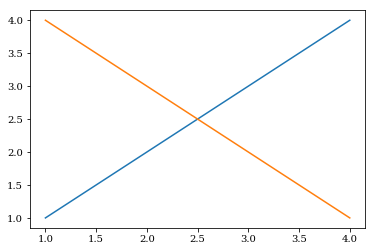

In [217]:
# Examle 1
## Simple lines

import matplotlib.pyplot as plt
import numpy as np

#plt.figure(facecolor='y')
#plt.figure(figsize=(6,4))

A = np.array([1,2,3,4])
B = np.array([4,3,2,1])

x = np.arange(1,5)

# Multiple sets in a single call
plt.plot(x,A,x,B)

#for i in range(2):
#   # random array(4) of integer between 0 and 5
#   C = np.random.randint(0,5,4)
#   # Multiple times call
#   plt.plot(x,C)
plt.show()


### Properties of line ( useful for plot and scatter)
- String annotation
    - '-g'  *# solid green*
    - --c'  *# dashed cyan* 
- Parameters
    - color, linestyle, marker
        - [ 'blue', 'b', '#0000FF', (0.0, 0.0, 1.0) ]
        - [ 'solid' '-' , 'dashed' '--' , 'dashdot' '-.' , 'dotted' ':' ]
        - point '.' , triangle_up '^', square 's' , ...
    - linewidth
    - markersize

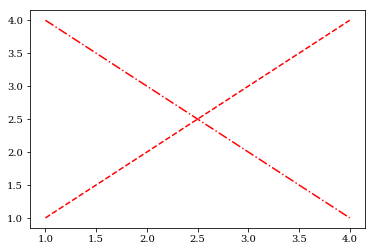

In [219]:
# Examle 2
## Simple lines - Change properties of lines
import matplotlib.pyplot as plt
import numpy as np
A = np.array([1,2,3,4])
B = np.array([4,3,2,1])
x = np.arange(1,5)
# Multiple sets in a single call
plt.plot(x,A,'r--',x,B,'r-.')
lines = []
#for i in range(2):
#    # random array(4) of integer between 0 and 5
#    C = np.random.randint(0,5,4)
#    # Multiple times call
#    handle, = plt.plot(x,C)
#    lines.append(handle)
## Modify properties at convenience
## Line2D objects
#lines[0].set_color('green')
#lines[0].set_linestyle(':')
#lines[0].set_marker('^')
#lines[1].set_color('cyan')
#lines[1].set_linestyle('-')
#lines[1].set_marker('o')

plt.show()

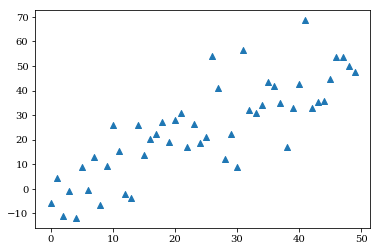

In [220]:
## Example 3
## Scatter
import matplotlib.pyplot as plt
import numpy as np
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)
       }
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

plt.scatter('a', 'b', data=data, marker='^')
#plt.scatter('a', 'b', c='c', s='d', data=data)

plt.show()


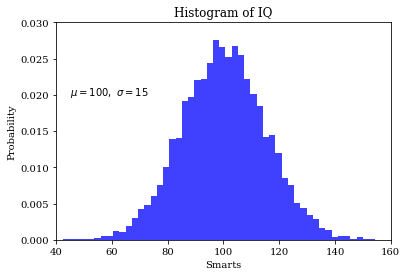

In [50]:
## Example 4
## Histogram
import matplotlib.pyplot as plt

mu, sigma = 100, 15
x = mu + sigma * np.random.randn(10000)

# the histogram of the data
n, bins, patches = plt.hist(x, 50, density=1, facecolor='b', alpha=0.75)
#n, bins, patches = plt.hist(x, 50, density=1, alpha=0.75,histtype='step')

plt.xlabel('Smarts')
plt.ylabel('Probability')
plt.title('Histogram of IQ')
plt.text(45, 0.020, r'$\mu=100,\ \sigma=15$')
plt.axis([40, 160, 0, 0.03])
plt.grid=True
plt.show()

In [5]:
### Parse files and get data
### Backend -- Not a plot!

import pickle
import random
import csv
import glob
import numpy as np
from matplotlib import pyplot as PLT

## Folder containing raw data
folder=glob.glob("data/download/*")

### Read data from files and create a dictionary holding the information
### output is dictionary containing lists
dictYear = dict()
for file in folder[:] :
    filename=file.split("/")[-1]

    with open(file, 'rt') as f:
        lineData = list()
        reader = csv.reader(f, delimiter='\t', skipinitialspace=True)
        cols = next(reader)
        for col in cols:
            # Create a list in lineData for each column of data.
            lineData.append(list())

        for line in reader:
            # column 1 and 2
            for i in range(0, len(lineData)):
                # Copy the data from the line into the correct columns.
                lineData[i].append(line[i])

        data = dict()
        for i in range(0, len(cols)):
            # Create each key in the dict with the data in its column.
            data[cols[i]] = lineData[i]
    # add the list to the dictionary
    dictYear[filename]=data


### Get information of the loaded structure

####  Get categories. X axis
season_samples=len(dictYear)

## Different classes. Number of cores
seasons = []
ucores = []
for key, value in dictYear.items() :
    seasons.append(key)
    new = dictYear[key]["Cores_per_Socket"]
    ucores = list(set().union(new, ucores))
ucores=[int(x) for x in ucores]

ucores.sort()
seasons.sort()


## Create a Matrix of  = Seasons * unique_cores
hpc_core = np.zeros((season_samples,len(ucores)))
## iterate over the structure and get cores per year.
x=0
for season, content in sorted(dictYear.items()) :
    ### iterate over unique core list
    y=0
    for core in ucores[:]:
        list_values=dictYear[season]['Count']
        list_cores=dictYear[season]['Cores_per_Socket']

        if str(core) in list_cores:
            # get index
            index=list_cores.index(str(core))
            hpc_core[x][y]=list_values[index]
        y+=1
    x+=1

hpc_core_acum=np.cumsum(hpc_core,axis=1)

file = open('data/top500.pickle','wb')
pickle.dump(hpc_core, file)
pickle.dump(hpc_core_acum, file)
pickle.dump(ucores,file)
pickle.dump(seasons,file)
file.close()

print("Data has been generated!")



Data has been generated!


In [51]:
## Example 5a
## Stacked area plot A
import pickle; import numpy as np; import matplotlib.pyplot as plt; import random
## Read filie to obtain data and labels
file = open('data/top500.pickle','rb')
hpc_core_data = pickle.load(file).T   ## samples
hpc_core = pickle.load(file)          ## stacked data
ucores = pickle.load(file)            ## labels
seasons = pickle.load(file)           ## time 
file.close()

## ...continues

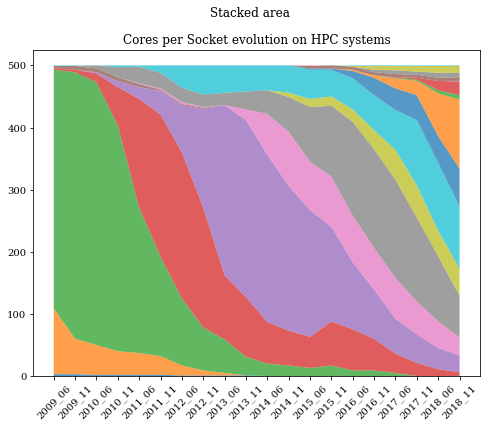

In [221]:
### Example 5b

fig = plt.figure(figsize=(8,6))
plt.suptitle('Stacked area')
ax1=fig.gca()
ax1.set_title('Cores per Socket evolution on HPC systems')
plt.xticks(rotation=45)
# random colors
#colors=[]
#for x in range(1,len(seasons)):
#    color = "#%06x" % random.randint(0, 0xFFFFFF)
#    colors.append(color)

plt.stackplot(seasons,hpc_core_data,labels=ucores,
#              colors=colors,
              alpha=0.75)

#ax1.legend(loc='right', shadow=True, fontsize='medium', bbox_to_anchor=(1.3,0.5), ncol=2)

plt.show()


## Decorations

In [56]:
## Example 6a

## Stacked area plot B
import pickle
import numpy as np
import matplotlib.pyplot as plt
import random

## Read filie to obtain data and labels
file = open('data/top500.pickle','rb')
hpc_core_data = pickle.load(file).T
hpc_core = pickle.load(file)
ucores = pickle.load(file) 
seasons = pickle.load(file)
file.close()


### ... continues



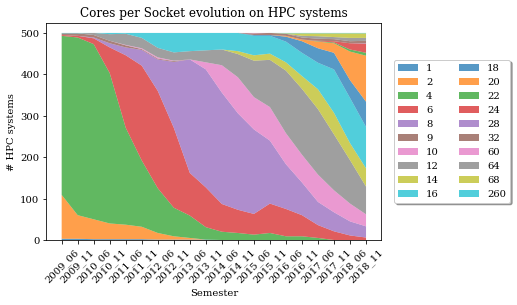

In [65]:
# Example 6b
# This is the basic plot
ax1 = plt.figure(frameon=True, linewidth=20).add_subplot(111)
plt.stackplot(seasons,hpc_core_data,labels=ucores,alpha=0.75)
ax1.legend(loc='right', shadow=True, fontsize='medium', bbox_to_anchor=(1.4,0.5), ncol=2)
# This is basic information
ax1.set_title('Cores per Socket evolution on HPC systems')
ax1.set_ylabel("# HPC systems")  
ax1.set_xlabel("Semester")
plt.xticks(rotation=45)
## Annotate the plot
#ax1.grid(True); 
#ax1.set_frame_on(False)
#ax1.axvline(x=8 , color='b', linestyle='--')
#ax1.axvline(x=4 , color='b', linestyle='--')   
#ax1.axvline(x=1 , linewidth=2, color='k', linestyle='-') 
#ax1.axhline(y=100,linewidth=2, color='k', linestyle='-')
### Text in de the middle of the plot
#plt.text(0.5, 0.5, 'pretty messy plot', 
#         size='x-large', 
#         horizontalalignment='center', 
#         verticalalignment='center', 
#         transform=ax1.transAxes)
plt.show()


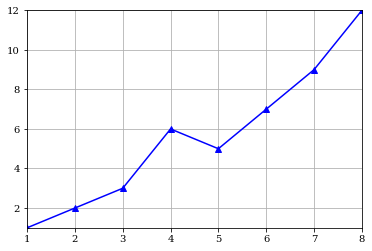

In [212]:
# Example 7
## More decorations

import matplotlib.pyplot as plt

x = [1,2,3,4,5,6,7,8]  #fake data
y = [1,2,3,6,5,7,9,12]

fig = plt.figure()
ax = plt.subplot()

ax.plot(x, y, 'b', marker='^')
ax.grid()
ax.margins(0) # remove default margins (matplotlib verision 2+)

#ax.axvspan(0, 4, facecolor='green', alpha=0.6)
#ax.axhspan(4, 9, facecolor='yellow', alpha=0.4)
#ax.axvspan(9, 12, facecolor='red', alpha=0.3)

plt.show()

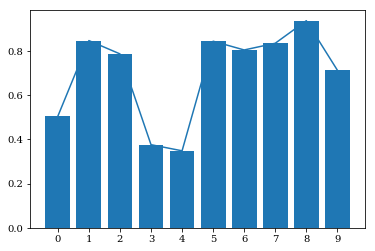

In [81]:
## Example 8
## Combined plot
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.gca()
xs = np.arange(10)
ys = np.random.rand(10)
ax.set_xticks(np.arange(10))

mybar = ax.bar(xs, ys)
mylines, = ax.plot(xs, ys)

#mylines.set_color('yellow')
#mylines.set_marker('^')
#mylines.set_markersize(16)
#mylines.set_linewidth(4)
#
#print(len(mybar.get_children()))
#
#mybar.get_children()[3].set_color('purple')
#
#ax.set_facecolor('orange')
#ax.set_alpha(0.5)

plt.show()


#### HELP with colors? 

[Color ][1]

<!--  
![title](https://oss.adm.ntu.edu.sg/limh0131/wp-content/uploads/sites/413/2015/10/059c1fb7c18c3b2314ca5a0b3e56780d.gif)
-->

[Video: Understanding color (harmonies)][2]

[1]: https://oss.adm.ntu.edu.sg/limh0131/wp-content/uploads/sites/413/2015/10/059c1fb7c18c3b2314ca5a0b3e56780d.gif
[2]: https://www.youtube.com/watch?v=Qj1FK8n7WgY&t=1s


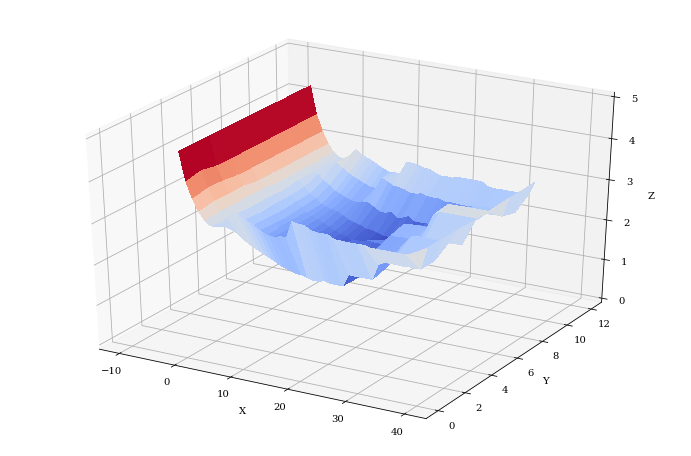

In [98]:
# Example 9
#from mpl_toolkits.mplot3d import axes3d; 
import matplotlib.pyplot as plt; from matplotlib import cm; import numpy as np                                                     
Z=np.loadtxt(open("data/times_affinity.csv", "rt"), delimiter=",", skiprows=1,usecols=(np.arange(1,11)))
Z=np.log(Z).T
fig = plt.figure(figsize=(12,8))                                               
ax = plt.axes(projection='3d')                                                                                                                              
X=np.arange(0,40,1)
Y=np.arange(0,10,1)
X, Y = np.meshgrid(X, Y)

#cset = ax.contourf(X, Y, Z, zdir='x', offset=-10, alpha=0.5, cmap=cm.coolwarm)
#cset = ax.contourf(X, Y, Z, zdir='y', offset=14,  alpha=0.5, cmap=cm.coolwarm)
#cset = ax.contourf(X, Y, Z, zdir='z', offset=0 ,  alpha=0.5, cmap=cm.coolwarm)   
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#fig.colorbar(surf, drawedges='True',shrink=0.8, aspect=18, orientation='vertical',)
#surf = ax.plot_wireframe(X, Y, Z, rstride=1, cstride=1)

ax.azim = -60
ax.elev = 30
ax.auto_scale_xyz([-10, 40], [0, 12], [0, 5])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Heatmap - multiplot

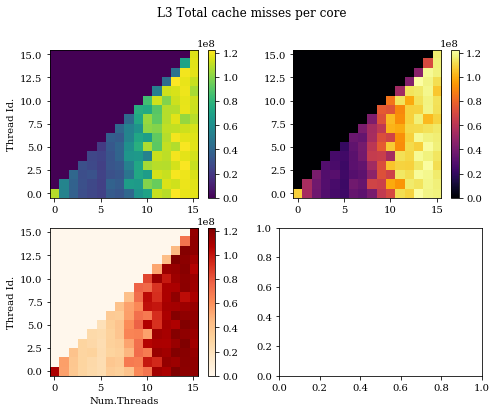

In [227]:
# Example 10
import matplotlib.pyplot as plt
matrix=np.loadtxt(open("data/heatmap.csv", "rt"), delimiter=",", skiprows=1,usecols=(np.arange(5,21))).T
# Create a figure and get axis
fig = plt.figure()
ax1 = fig.add_subplot(221) 
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
fig.set_size_inches(8,6)
hm1 = ax1.imshow(matrix,                 origin='lower')
hm2 = ax2.imshow(matrix, cmap="inferno", origin='lower')
hm3 = ax3.imshow(matrix, cmap="OrRd",    origin='lower')
## associate colorbars
cbar1 = fig.colorbar(hm1, ax=ax1); cbar2 = fig.colorbar(hm2, ax=ax2); cbar3 = fig.colorbar(hm3, ax=ax3)
plt.suptitle("L3 Total cache misses per core")
ax3.set_xlabel("Num.Threads")
ax1.set_ylabel("Thread Id."); ax3.set_ylabel("Thread Id.")
plt.show()


# Multi plot

- Subplot
- GirdSpec
- Arrangements 1
- Arrangements 2
- Histogram multiplot


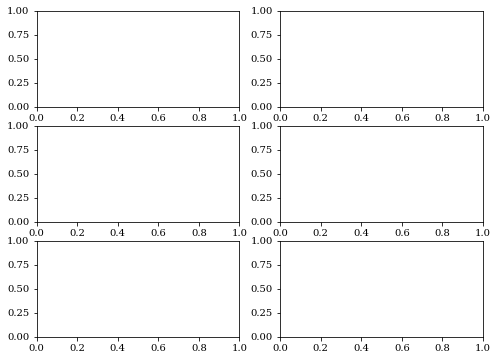

In [233]:
## Example 7
## subplot
import matplotlib.pyplot as plit
import matplotlib.image as mpimg
img = mpimg.imread('fig/vis_free_banana.png')

fig=plt.figure()
fig.set_size_inches(8,6)
ax1 = fig.add_subplot(321) 
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)

#ax1.imshow(img);              ax2.imshow(img[:,:,0])
#ax3.imshow(img[:,:,1]);       ax4.imshow(img[:,:,2])
#ax5.imshow(img[:,:,3]);       ax6.axis('off')
plt.show()


### Adding subplot - Grid control

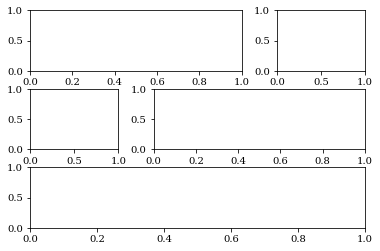

In [228]:
### Example 8
## grid control A
import matplotlib

img = mpimg.imread('fig/vis_free_banana.png')

grid = plt.GridSpec(3, 3, wspace=0.4, hspace=0.3)

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2])
ax3 = plt.subplot(grid[1, 0])
ax4 = plt.subplot(grid[1, 1:3]);
ax5 = plt.subplot(grid[2, 0:3]);

#ax1.imshow(img, aspect='auto');         ax2.imshow(img[:,:,0], aspect='auto') 
#ax3.imshow(img[:,:,1], aspect='auto');  ax4.imshow(img[:,:,2], aspect='auto')
#ax5.imshow(img[:,:,3], aspect='auto')
plt.show()



### Adding subplot - Controlling the grid

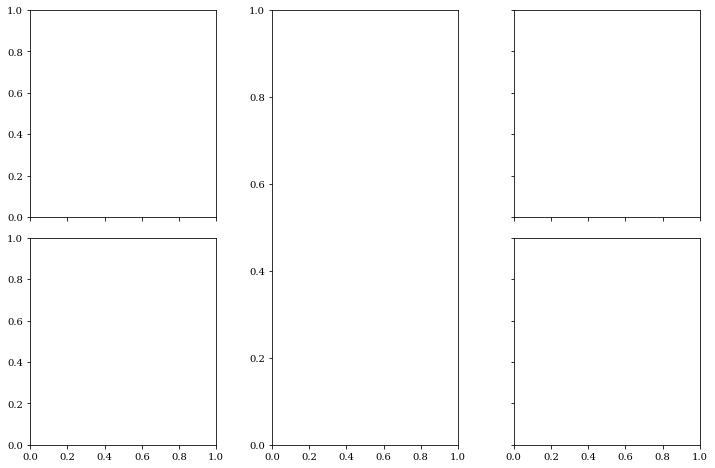

In [229]:
### Example 9
### Grid control B
import matplotlib
import matplotlib.image as mpimg
img = mpimg.imread('fig/vis_free_banana.png')

plt.figure(figsize=(12,8))
grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.1)  

ax1 = plt.subplot(grid[0, 0],);     plt.setp(ax1.get_xticklabels(), visible=False)
ax2 = plt.subplot(grid[0, 2]);      plt.setp(ax2.get_yticklabels(), visible=False); plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = plt.subplot(grid[1, 0])
ax4 = plt.subplot(grid[1, 2]);      plt.setp(ax4.get_yticklabels(), visible=False)
ax5 = plt.subplot(grid[0:2, 1])

#ax1.imshow(img);         ax2.imshow(img[:,:,0])
#ax3.imshow(img[:,:,1]);  ax4.imshow(img[:,:,2])
#ax5.imshow(img[:,:,3])
plt.show()

### Adding subplot - Fine arragement

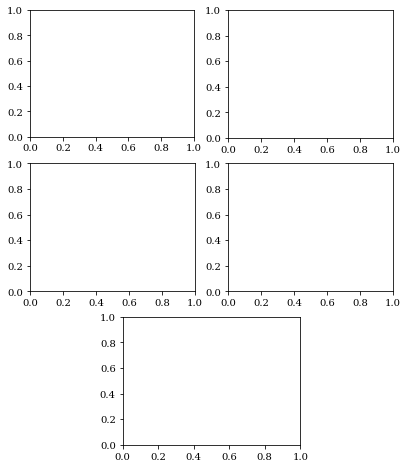

In [244]:
## Example 10
## Fine arragement
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import axes3d
img = plt.imread('fig/vis_free_banana.png')

fig = plt.figure(figsize=(6.5,8))

# add low level axes:  x ,  y  ,  xsize, ysize
ax1 = fig.add_axes([0.125, 0.66, 0.35, 0.22]) ## from bottom, left.
# normal way
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
# new subdivision
ax5 = plt.subplot2grid((3,8),(2,2),colspan=4)

#ax1.imshow(img);        ax2.imshow(img[:,:,0])
#ax3.imshow(img[:,:,1]); ax4.imshow(img[:,:,2])
#ax5.imshow(img[:,:,3]); 
plt.show()


## Spectrogram multiplot

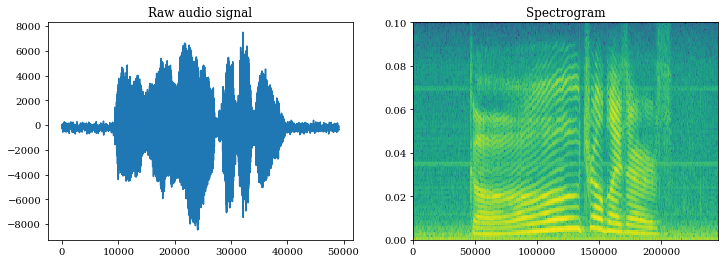

In [209]:
from scipy.io import wavfile
from matplotlib import pyplot as plt
## mono audio file   # 49152 samples
rate, x = wavfile.read('sounds/test_000.wav')

b=x[:].copy()

## Create al subplots at once
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))

ax1.set_title('Raw audio signal')
ax1.plot(b[:])
ax2.specgram(b[:], Fs = 0.2)
ax2.set_title('Spectrogram')

plt.show()


# Extension - Other plots as packages

- Graphs
- Sankey diagrams

### Additional packages: 
- networkx
- jgraph
- pySankey

### Graphs

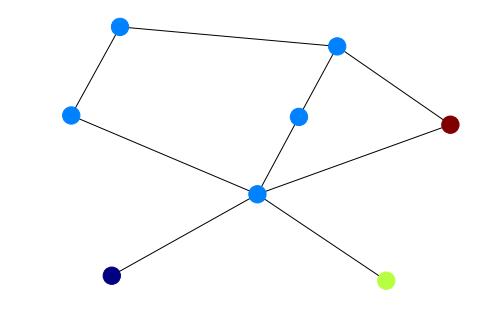

In [19]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from(
    [('A', 'B'), ('A', 'C'), ('D', 'B'), ('E', 'C'), ('E', 'F'),
     ('B', 'H'), ('B', 'G'), ('B', 'F'), ('C', 'G')])

val_map = {'A': 1.0,
           'D': 0.5714285714285714,
           'H': 0.0}

values = [val_map.get(node, 0.25) for node in G.nodes()]

nx.draw(G, cmap = plt.get_cmap('jet'), node_color = values)

plt.show()

In [20]:
import jgraph
#jgraph.draw([(1, 2), (2, 3), (3, 4), (4, 1), (4, 5), (5, 2)])
jgraph.draw([(1, 2), (2, 3), (3,1), (3,4), (4,1)])


## Sankey plots

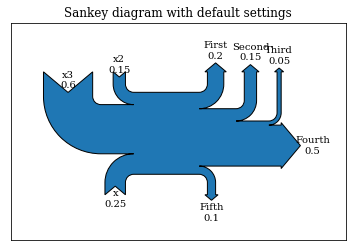

In [245]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey


snk = Sankey(flows=[0.25, 0.15, 0.60, -0.20, -0.15, -0.05, -0.50, -0.10], 
       labels=['x', 'x2', 'x3', 'First', 'Second', 'Third', 'Fourth', 'Fifth'], 
       orientations=[-1, 1, 1, 1, 1, 1, 0,-1])

snk.finish()

plt.title("Sankey diagram with default settings")

plt.show()


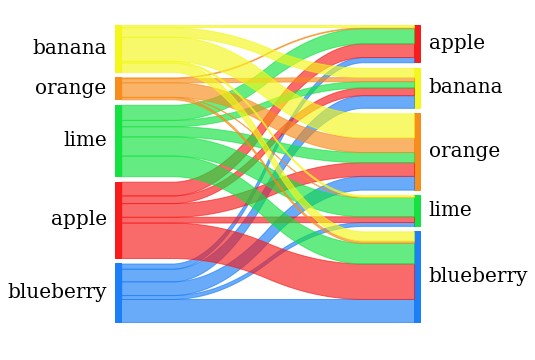

In [247]:
from pySankey import sankey
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/fruits.txt',sep = ' ',names=['true','predicted'])

#print(df)

colorDict =  {'apple':'#f71b1b','blueberry':'#1b7ef7','banana':'#f3f71b','lime':'#12e23f','orange':'#f78c1b'}

sankey.sankey(df['true'],df['predicted'],colorDict=colorDict,fontsize=20,)

plt.gcf().set_size_inches(6,6)
plt.show()


<H1><center>Thanks for your attention</center></H1>